# Google Play Store Dataset EDA :----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset & Create Copy

In [2]:
url = "https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv"
df = pd.read_csv(url)
df_copy = df.copy()

### 2. Drop Corrupted Row (Shifted entry at index 10472)

In [3]:
df_copy = df_copy.drop(df_copy.index[10472])

### 3. Clean 'Size' Column (Handle MB, KB, and 'Varies with device')

In [4]:
df_copy['Size'] = df_copy['Size'].str.replace('M', '000')
df_copy['Size'] = df_copy['Size'].str.replace('k', '')
df_copy['Size'] = df_copy['Size'].replace('Varies with device', np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)

### 4. Clean Special Characters from 'Installs' and 'Price'

In [7]:
chars_to_remove = ['+', ',', '$']
cols_to_clean = ['Installs', 'Price']

for item in chars_to_remove:
    for col in cols_to_clean:
        df_copy[col] = df_copy[col].str.replace(item, '')

df_copy['Installs'] = df_copy['Installs'].astype(int)
df_copy['Price'] = df_copy['Price'].astype(float)

### 5. Parse 'Last Updated' Date Strings into Day, Month, Year

In [8]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

### 6. Automated Univariate KDE Plot Loop for Numerical Features

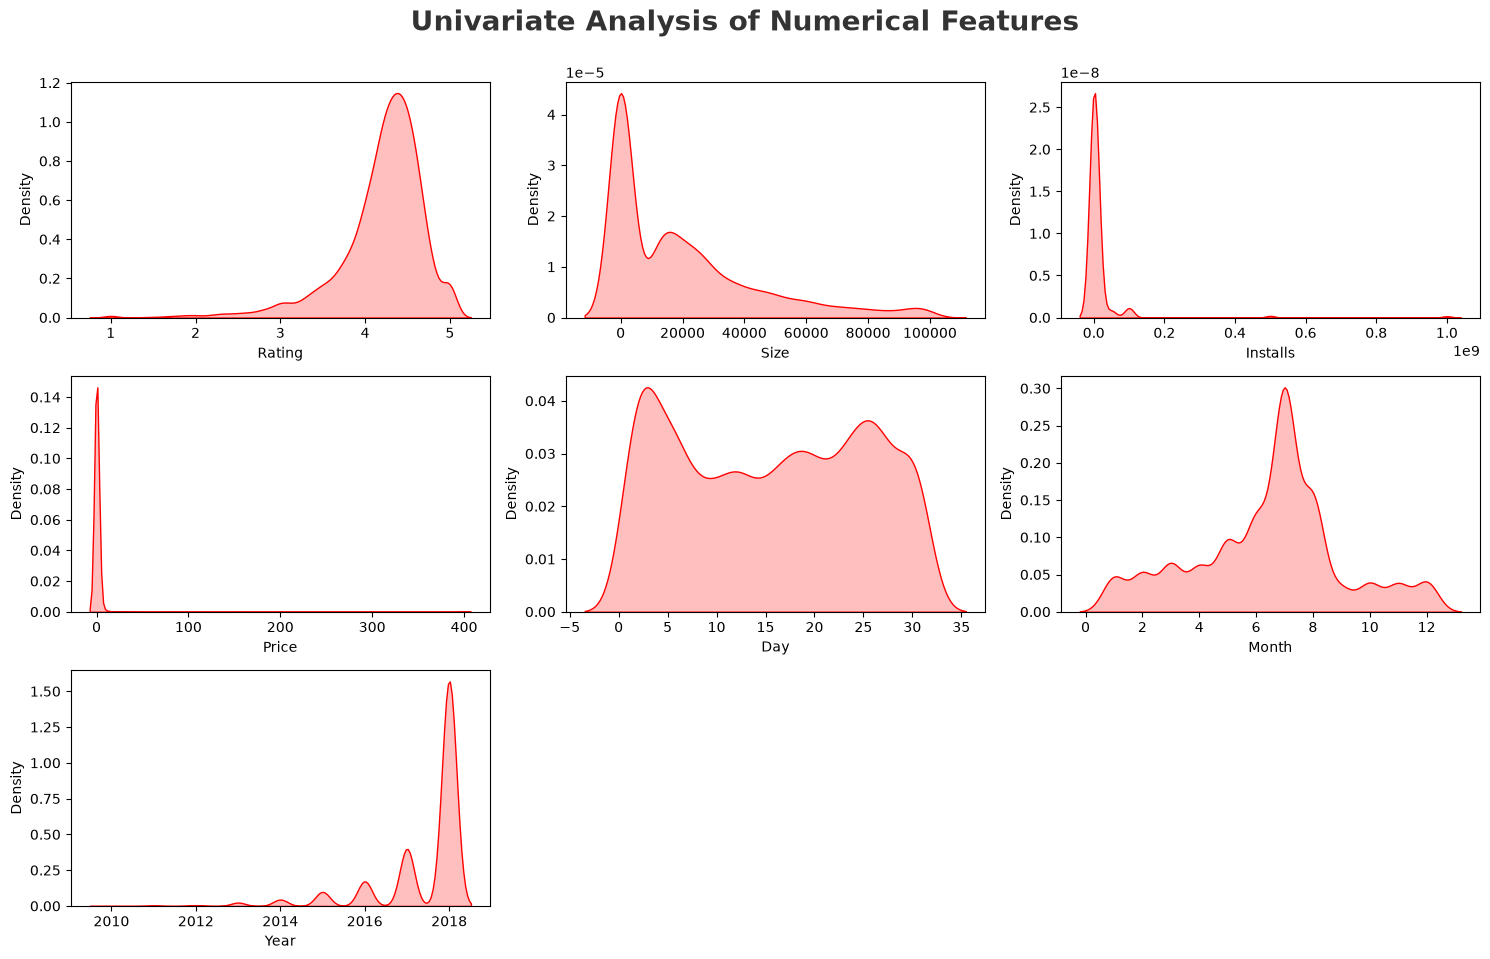

In [12]:
numeric_features = df_copy.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.0)

for i in range(len(numeric_features)):
    plt.subplot(5, 3, i + 1)
    sns.kdeplot(x=df_copy[numeric_features[i]], fill=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

plt.show()